# Higgs Effective Field Theory (HEFT) Study: Testing
> Created: Aug 21, 2026 Pushpa Bhat (Fermilab), Nicola de Filippis (Bari),<br> Kurtis Johnson,  Harrison B. Prosper, Ryne Starnes (FSU)<br>

## Introduction

See Introduction in `heft_train.ipynb`. This notebook compares the di-Higgs differential  cross section predicted by the saved ML model and POWHEG. 

In [1]:
import os, sys

# the standard module for tabular data
import pandas as pd

# the standard module for array manipulation
import numpy as np

# the standard modules for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# pytorch
import torch

# module for shell utilities
import shutil

# di-Higgs ML module
import dihiggs.nn as mlp

# update fonts
plt.rcParams.update({
  "text.usetex": shutil.which('latex') is not None,
  "font.family": "sans-serif",
  "font.size": 12
})

## Load configuration

In [2]:
# Name of model
DIRNAME = 'L1Loss'
NAME    = 'dihiggs'
BASE    = f'runs/{DIRNAME}'

# Load configuration file
config = mlp.Config(f'{BASE}/{NAME}_config.yaml')
print(config)

name: dihiggs
file:
  config: runs/L1Loss/dihiggs_config.yaml
  losses: runs/L1Loss/dihiggs_losses.csv
  script: runs/L1Loss/dihiggs_script.pth
  params: runs/L1Loss/dihiggs_params.pth
  init_params: runs/L1Loss/dihiggs_init_params.pth
  plots: runs/L1Loss/dihiggs_plots.png
model_name: heftnet
features:
- mhh
- klambda
- CT
- CTT
- CGGH
- CGGHH
target: sigma
activation: nn.ReLU
batch_size: 2048
train_size: 301056
test_size: 50000
val_size: 6902
monitor_step: 100
frac: 0.015
n_steps: 4
n_iterations: 200000
n_iters_per_step: 50000
base_lr: 0.002
gamma: 0.5



## Load saved fully-loaded model

In [3]:
# Load saved model
model = torch.jit.load(config('file/script'))
model.eval()

RecursiveScriptModule(
  original_name=HEFTNet
  (P): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Linear)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Linear)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=Linear)
    (9): RecursiveScriptModule(original_name=ReLU)
    (10): RecursiveScriptModule(original_name=Linear)
    (11): RecursiveScriptModule(original_name=ReLU)
    (12): RecursiveScriptModule(original_name=Linear)
    (13): RecursiveScriptModule(original_name=Tanh)
  )
  (Q): RecursiveScriptModule(original_name=Linear)
)

## Plot coefficients

23


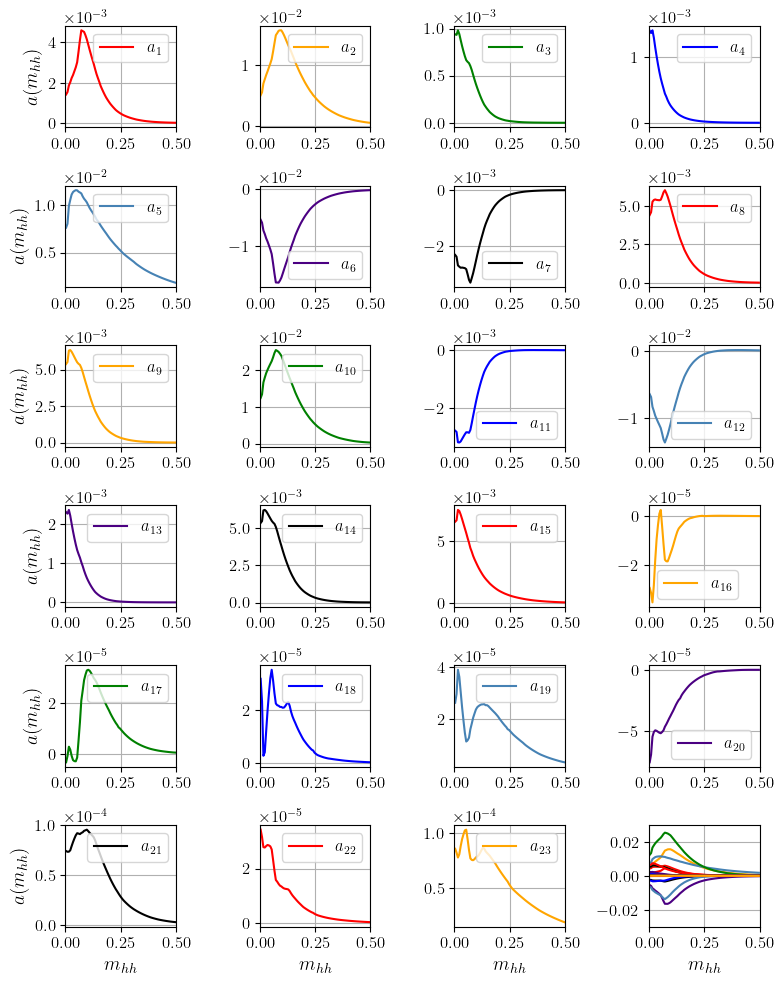

In [5]:
def plot_coeffs(dnn, ftsize=14, 
                filename=f'{BASE}/{NAME}_coefficients.png'):
    
    # define equally spaced points for m_hh
    xbins= 80
    xmin = 0
    xmax = 0.5
    x = np.linspace(xmin, xmax, xbins+1)
    x = (x[1:]+x[:-1])/2

    # detach from computation tree and return coefficients as a numpy array
    a = dnn.coeffs(torch.Tensor(x)).detach().numpy()
    nplots = len(a[0])
    print(nplots)
    
    # create a mosaic of plots
    # a b c
    # d e f
    # : : :
    # o p p
    # last plot occupies two slots
    fig, axes = plt.subplot_mosaic('abcd;'
                                   'efgh;'
                                   'ijkl;'
                                   'mnop;'
                                   'qrst;'
                                   'uvwx', 
                                   figsize=(8, 10))

    # get subplot keys a, b, c, etc.
    keys = list(axes.keys())
    keys.sort()

    kolor = ['red', 'orange', 'green', 'blue', 'steelblue', 'indigo', 'black']

    nrows = 6
    ncols = 4
    
    for i, key in enumerate(keys[:-1]):
        
        ax = axes[key]

        ax.set_xlim(xmin, xmax)
        
        if i > (nrows-1) * ncols-1:
            ax.set_xlabel(r'$m_{hh}$', fontsize=ftsize)
            
        if i % ncols == 0:
            ax.set_ylabel(r'$a(m_{hh})$', fontsize=ftsize)
            
        ax.ticklabel_format(axis='y', scilimits=[-2, 2])
        
        # plot (i+1)th coefficient
        y = a.T[i]
        c = kolor[i % len(kolor)]
        index = i + 1
        ax.plot(x, y, color=c, label='$a_{%d}$' % index)
        ax.legend()
        ax.grid()

    # last plot: superimpose all coefficient plots
    ax = axes['x']
    
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel(r'$m_{hh}$', fontsize=ftsize)

    ymin = -0.03
    ymax =  0.03
    ax.set_ylim(ymin, ymax)
    
    for i in range(nplots):
        # plot (i+1)th coefficient
        y = a.T[i]
        c = kolor[i % len(kolor)]
        index = i + 1
        ax.plot(x, y, color=c)
    ax.grid()
    
    # need the following to make layout look reasonable
    fig.tight_layout()

    plt.savefig(filename)
    plt.show()
    plt.close()
    
plot_coeffs(model)

## Plot spectra

 1. Compute spectra approximated with the NN model.
 2. Compare with POWHEG spectra that have ***not*** been used in the training.

### Load test spectra

In [6]:
spectra = pd.read_csv('../data/heft_wide_gauss_testdata_13TeV.csv')
print(f'Number of test spectra: {len(spectra)}')
spectra[:5]

Number of test spectra: 500


,ID,klambda,CT,CTT,CGGH,CGGHH,17,18,19,20,...,87,88,89,90,91,92,93,94,95,96
0,2573,5.548667,0.001127,-1.498415,1.167773,-0.800664,0.004168,0.001641,0.000328,0.000706,...,0.000738,0.000706,0.000673,0.000443,0.000624,0.000558,0.000443,0.000377,0.000558,0.000574
1,3405,1.362614,0.062098,-0.209365,-0.267593,1.521406,0.011459,0.015339,0.016459,0.016540,...,0.002272,0.001834,0.001932,0.001899,0.001769,0.001493,0.001834,0.001721,0.001867,0.001396
2,3430,3.267829,2.100274,2.011320,-2.948384,3.075786,0.010026,0.019230,0.028845,0.035501,...,0.008629,0.008464,0.007807,0.005835,0.006163,0.007396,0.007150,0.007067,0.005588,0.005259
3,1220,-1.888424,2.017534,0.538233,1.308303,-0.489064,0.130243,0.141480,0.156984,0.145855,...,0.000054,0.000054,0.000270,0.000054,0.000162,0.000108,0.000054,0.000108,0.000108,0.000216
4,4129,6.043734,0.092765,-1.787688,0.778852,-0.274286,0.001606,0.000450,0.000385,0.001831,...,0.000530,0.000289,0.000401,0.000273,0.000241,0.000498,0.000401,0.000337,0.000257,0.000337


In [10]:
def get_spectra(model, df, row):

    params = ['klambda', 'CT', 'CTT', 'CGGH', 'CGGHH']

    # Get Wilson coefficients for given HEFT point (row)    
    klambda, ct, ctt, cggh, cgghh = df[params].iloc[row]

    # Get column names of desired spectral bins
    n = list(spectra.columns[len(params)+1:]) # skip ID through CGGHH
    first_bin = int(n[0])
    last_bin  = int(n[-1])
    bins   = [f'{i}' for i in range(first_bin, last_bin+1)]

    # Get POWHEG cross sections into a numpy array for specified HEFT point
    spectrum = df[bins].iloc[row].to_numpy()

    # Compute mhh values (mid-point of bins)
    xbins = len(bins)
    xmin  = 0
    xmax  = xbins/100
    x = np.linspace(xmin, xmax, xbins+1)
    x = (x[1:]+x[:-1])/2

    # Create input tensor for NN model
    inputs = []
    for mhh in x:
        inputs.append([mhh, klambda, ct, ctt, cggh, cgghh])
    inputs = torch.Tensor(np.array(inputs))

    # Get NN predicted cross section
    model.eval()   
    y = model(inputs).detach().numpy()

    # Return:
    # 1. Total cross section
    # 2. x: di-Higgs mass
    # 3. y: NN-predicted spectrum
    # 4. spectrum: POWHEG spectrum
    # 5: Wilson coefficients
    
    return spectrum.sum(), x, y, spectrum, klambda, ct, ctt, cggh, cgghh

In [11]:
def plot_spectra(data, 
                 ftsize=12, 
                 filename=f'{BASE}/{NAME}_spectra_comparisons.png'):
    print(filename)
    
    plt.rcParams.update({'font.size': 12})
        
    _, x, y, s, _,_,_,_,_ = data[0]
    xbins = len(x)
    xmin, ymin  = 0, 0
    xmax = xbins/100

    # work out number of columns and number of plots
    ncols = 4
    nrows = len(data) // ncols
    ndata = nrows * ncols
    
    # create an empty figure
    fig = plt.figure(figsize=(12, 1.6*nrows))

    # loop over coefficients

    # Turn off LaTex
    plt.rcParams.update({"text.usetex": False})
    
    for i, (total_xsec, x, y, f, klambda, ct,ctt, cggh, cgghh) \
    in enumerate(data):

        index = i+1
        ax  = fig.add_subplot(nrows, ncols, index)

        # setup x-axis
        ax.set_xlim(xmin, xmax)
        
        if i > (nrows-1) * ncols-1:
            ax.set_xlabel(r'$m_{hh}$', fontsize=ftsize)

        # setup y-axis
        ymax = 1.5 * f.max()
        ax.set_ylim(ymin, ymax)
        ax.ticklabel_format(axis='y', scilimits=[-2, 2])
        
        if i % ncols == 0:
            ax.set_ylabel(r'$\sigma$', fontsize=ftsize)

        # annotate plot
        xpos = xmin + 0.02 * (xmax-xmin)
        ypos = ymin + 0.85 * (ymax-ymin)
        ystep= (ymax-ymin)/5
       
        ypos -= 0.5*ystep
        ax.text(xpos, ypos, '%5.2f,%5.2f,%5.2f,%5.2f,%5.2f' % \
                (klambda, ct, ctt, cggh, cgghh), fontsize=10)
        
        ypos -= ystep
        xpos = xmin + 0.40 * (xmax-xmin)
        ax.text(xpos, ypos, r'$\sigma:$ %5.2f pb' % total_xsec, 
                fontsize=12)
        
        # POWHEG spectra
        ax.hist(x, bins=xbins, range=(xmin, xmax), weights=f, 
                    color='green', alpha=0.2)

        # NN-approximated spectra
        ax.plot(x, y, color='blue', linewidth=2)

    fig.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()
# ------------------------------------------------------------------
M = len(spectra)
data = []
for row in range(M):
    data.append( get_spectra(model, spectra, row) )  
    
# sort in order of increasing cross section
data.sort()

0 20
runs/L1Loss/figures/spectra001.png


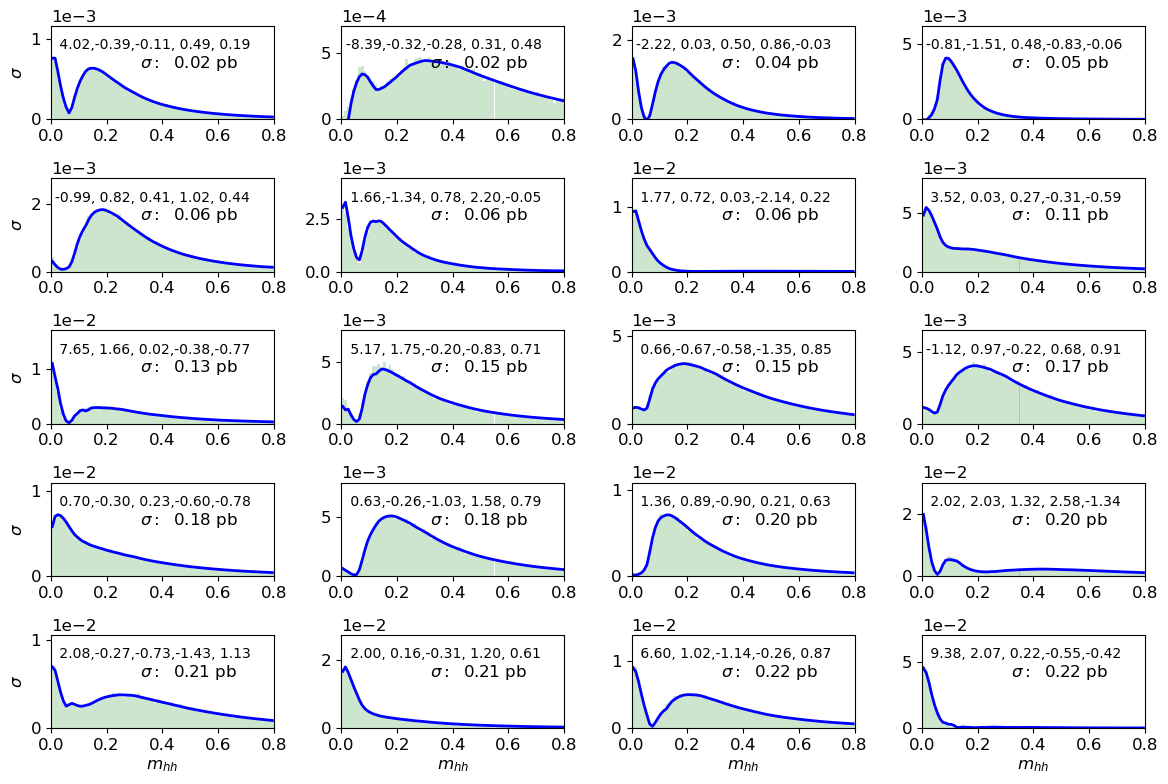

20 40
runs/L1Loss/figures/spectra002.png


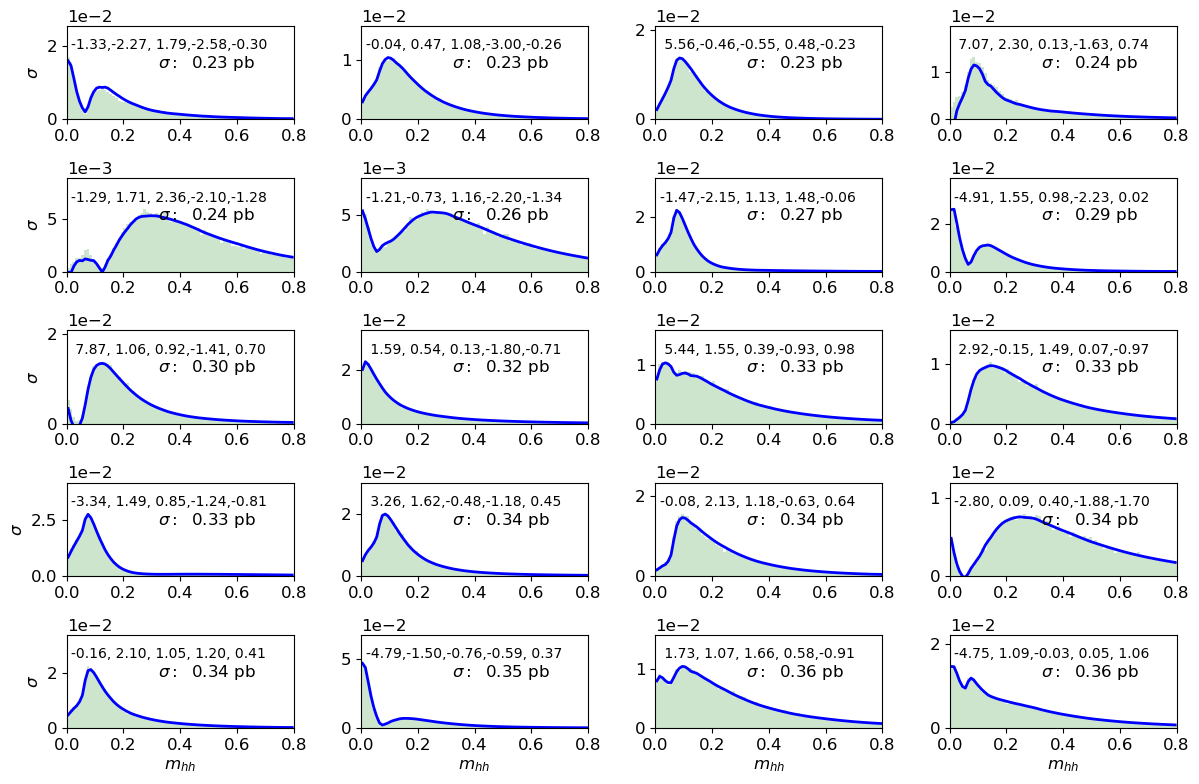

40 60
runs/L1Loss/figures/spectra003.png


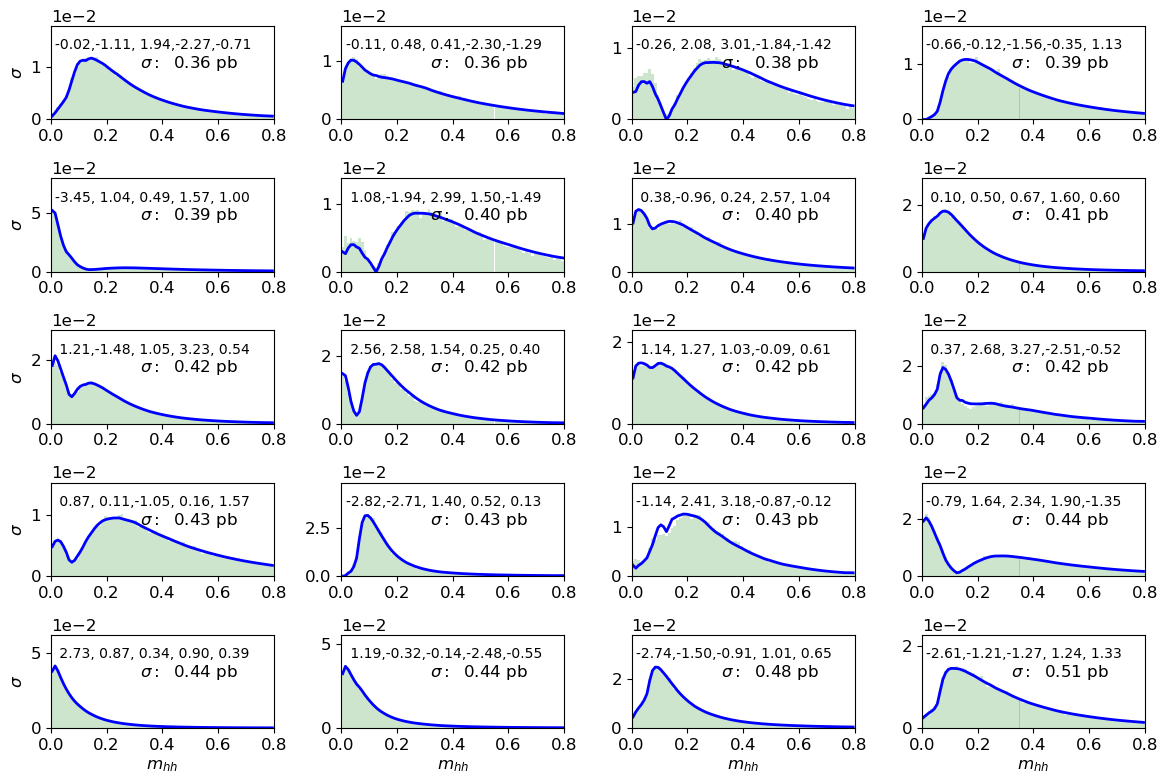

60 80
runs/L1Loss/figures/spectra004.png


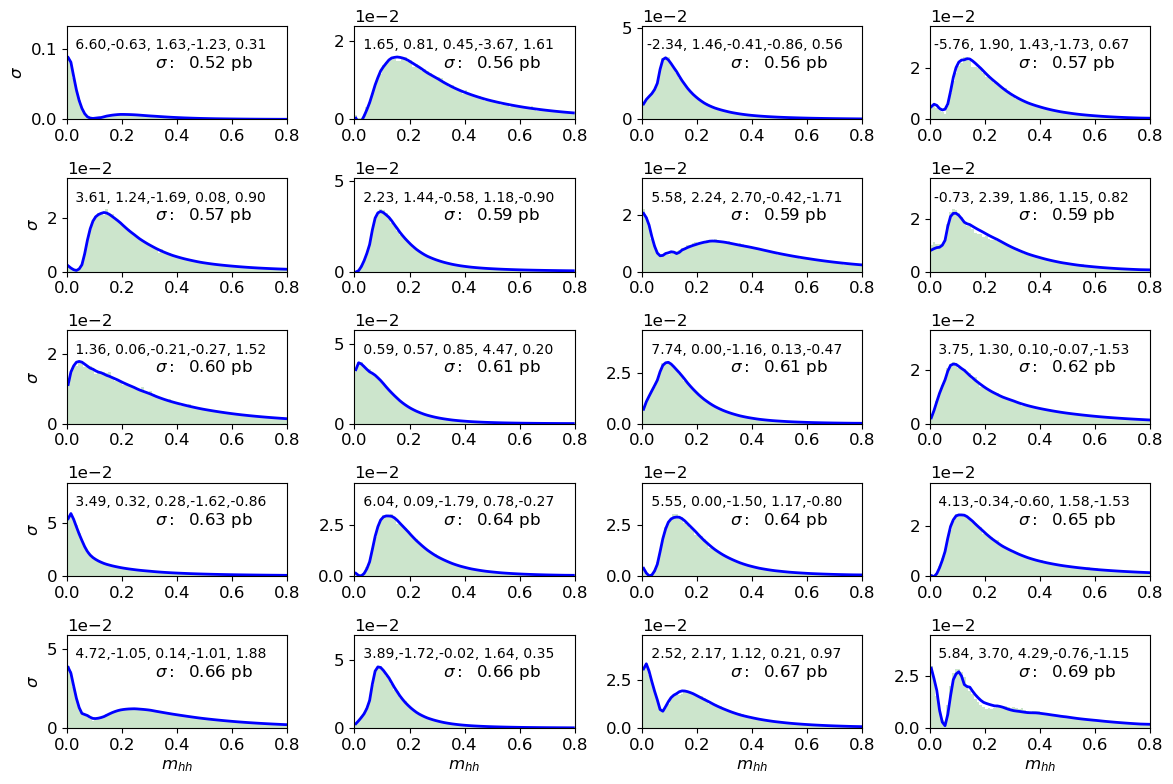

80 100
runs/L1Loss/figures/spectra005.png


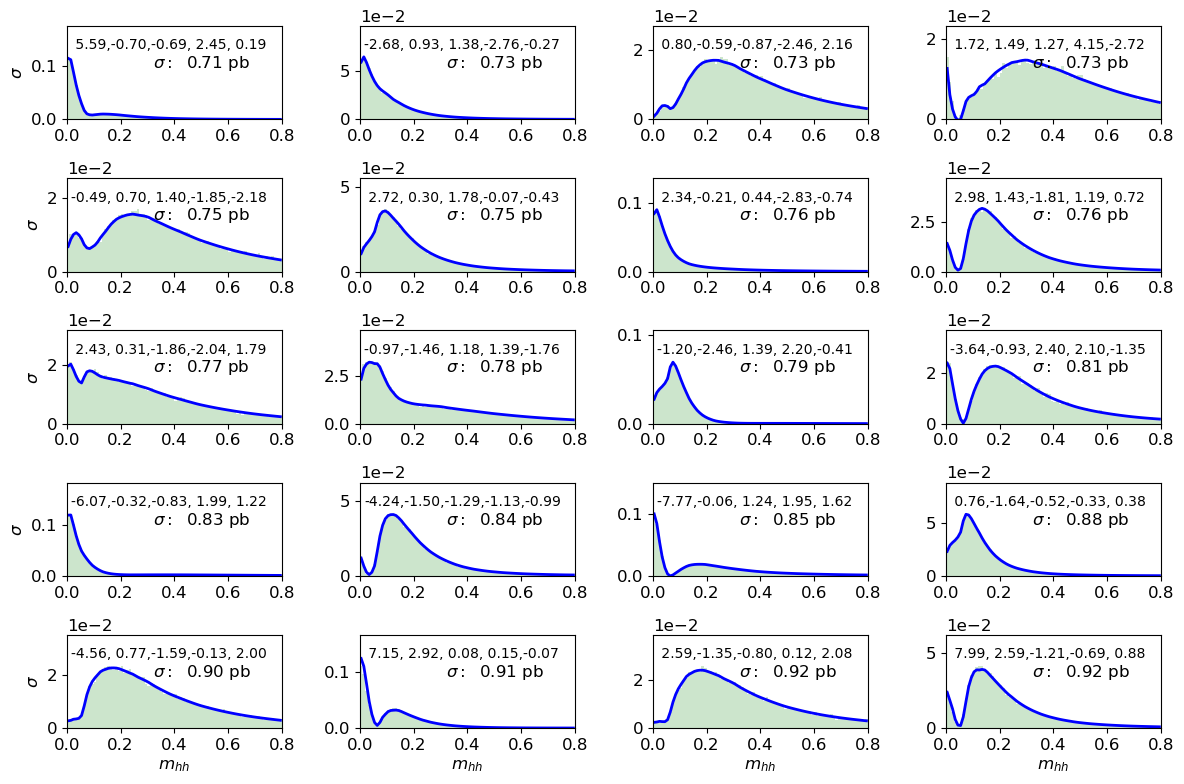

100 120
runs/L1Loss/figures/spectra006.png


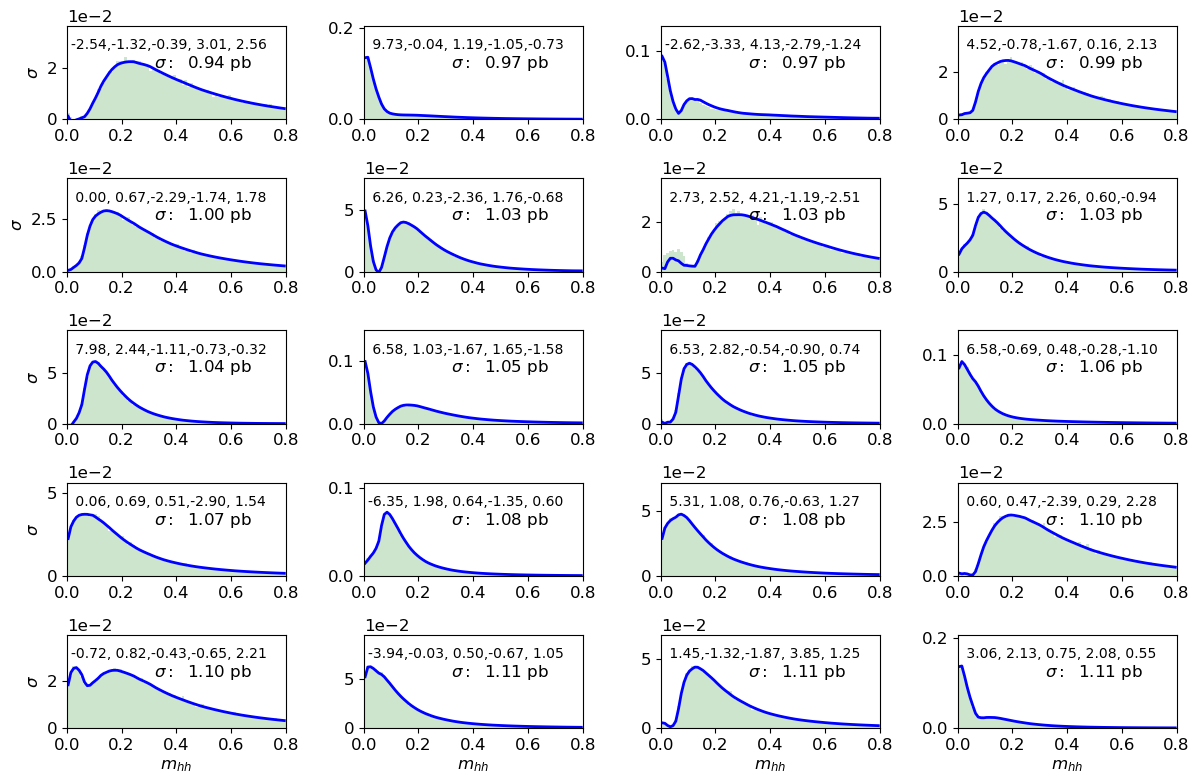

120 140
runs/L1Loss/figures/spectra007.png


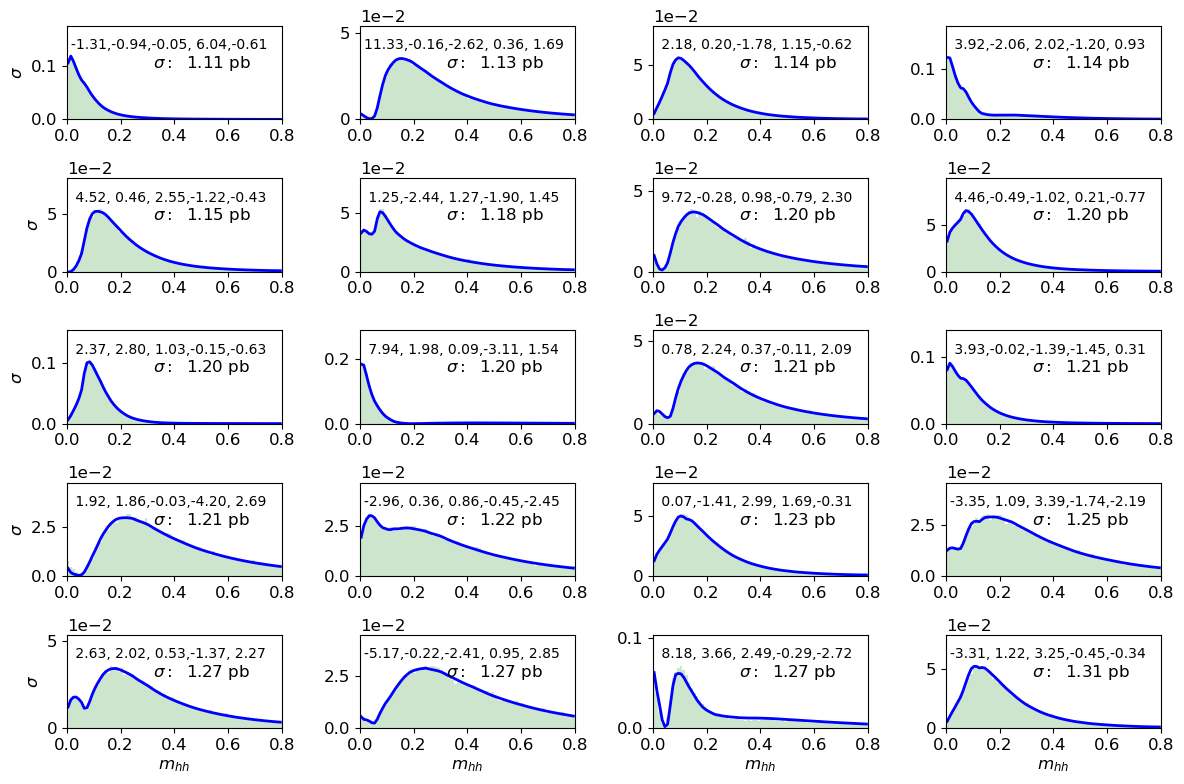

140 160
runs/L1Loss/figures/spectra008.png


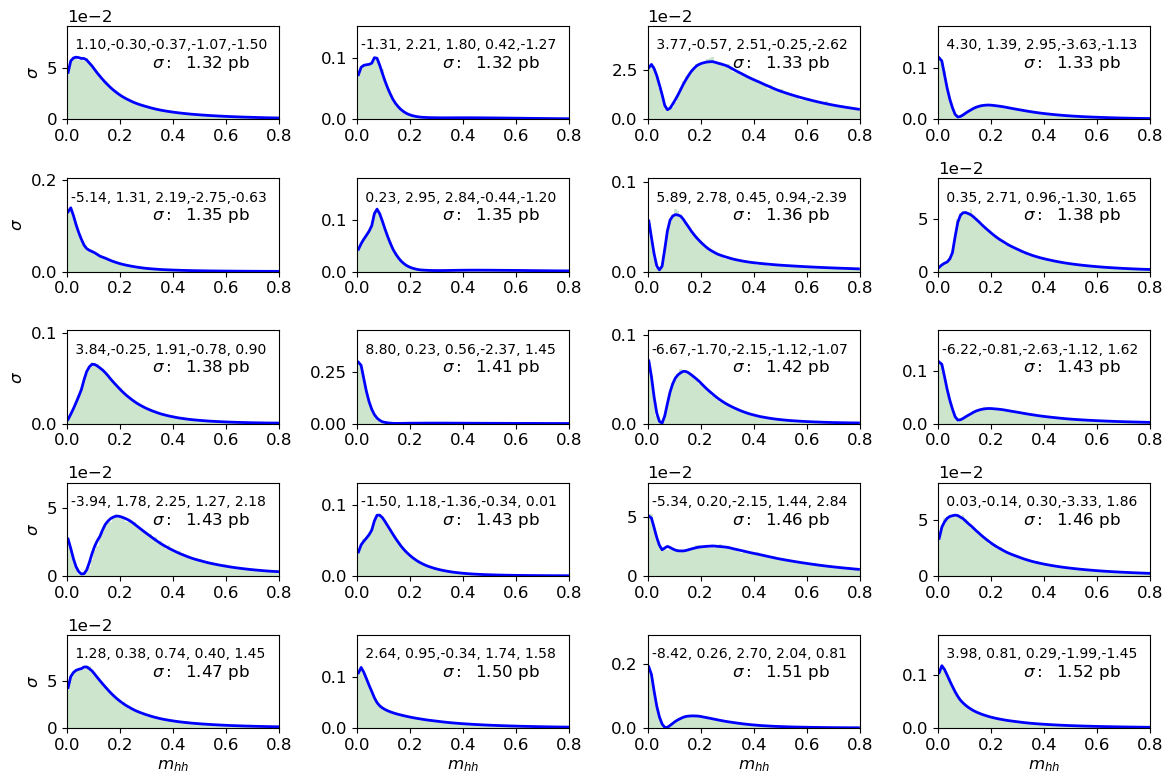

160 180
runs/L1Loss/figures/spectra009.png


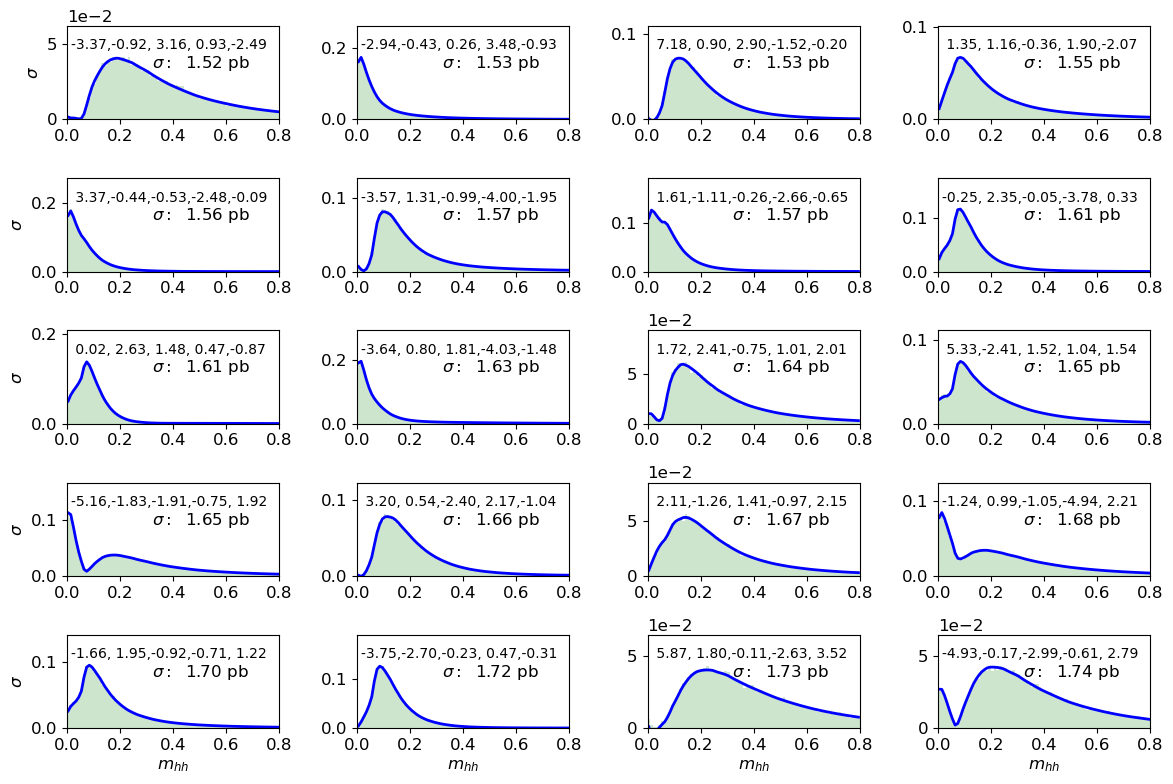

180 200
runs/L1Loss/figures/spectra010.png


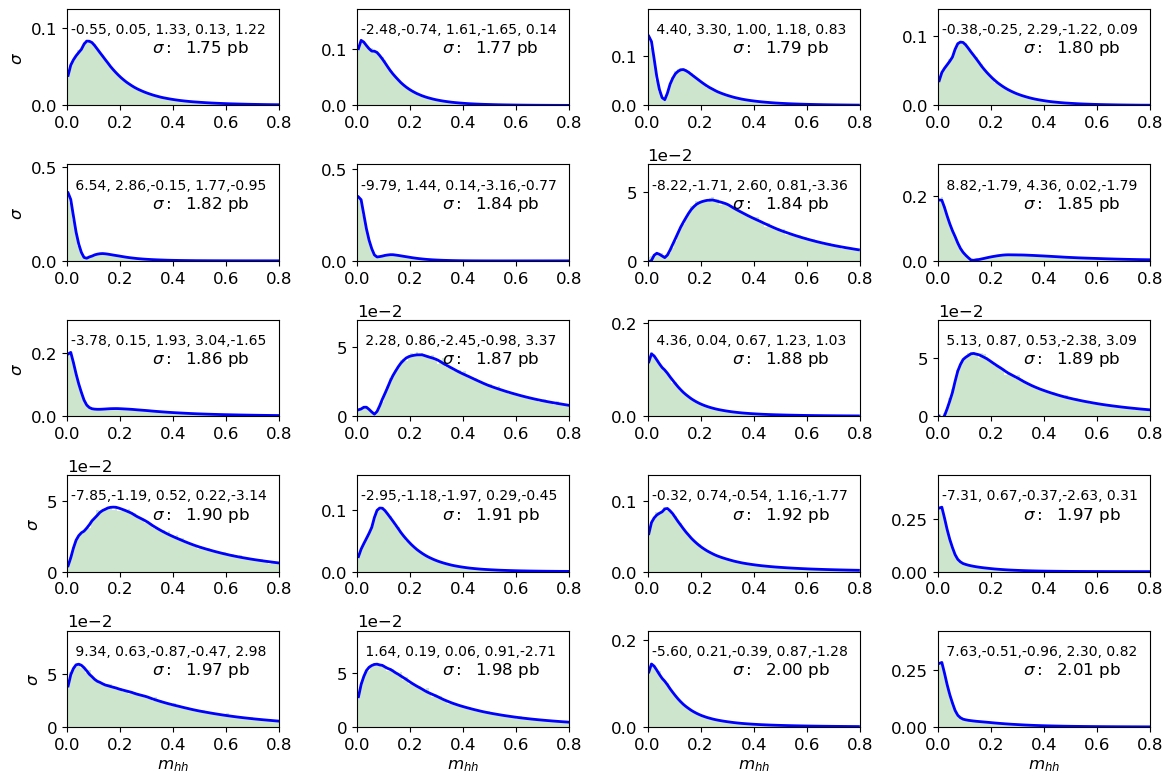

200 220
runs/L1Loss/figures/spectra011.png


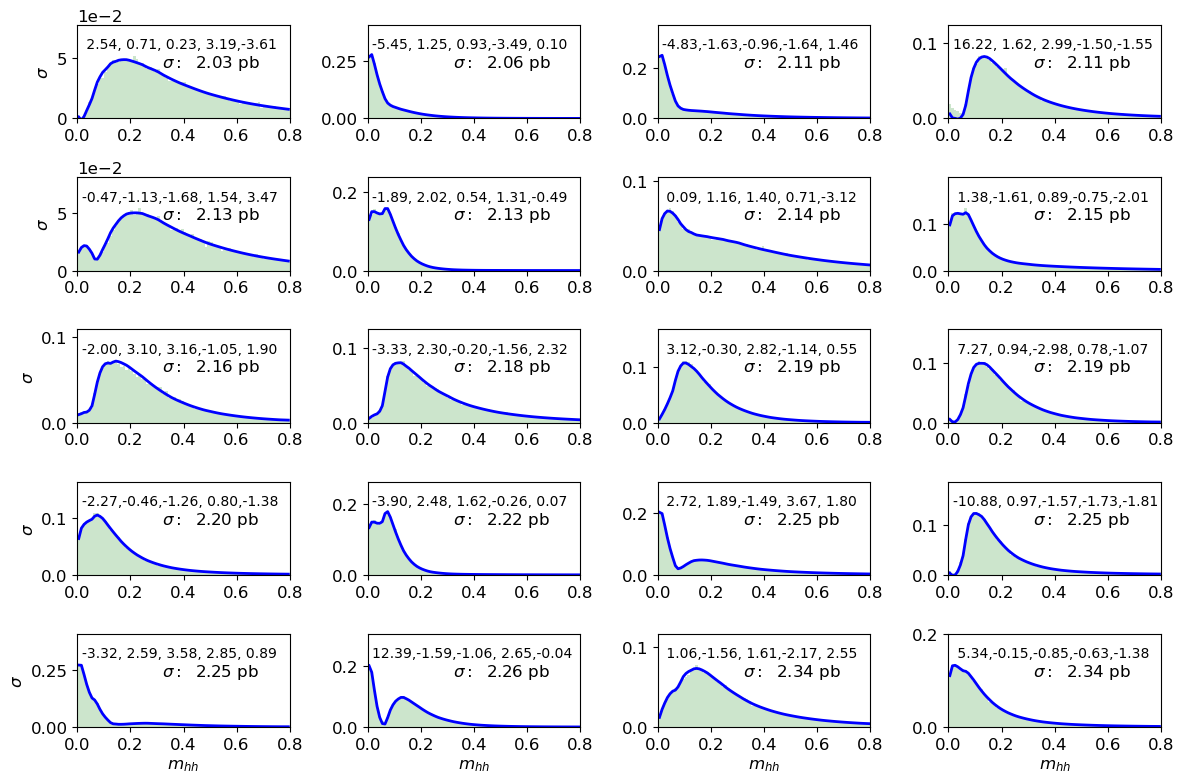

220 240
runs/L1Loss/figures/spectra012.png


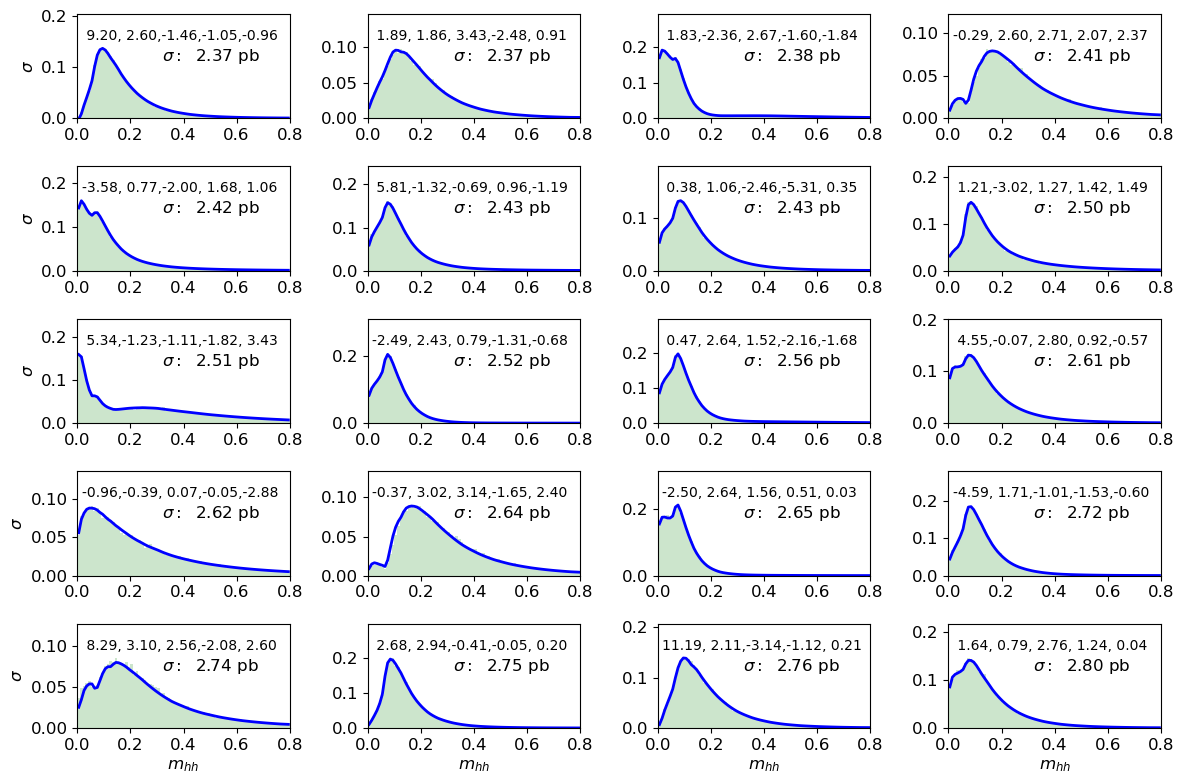

240 260
runs/L1Loss/figures/spectra013.png


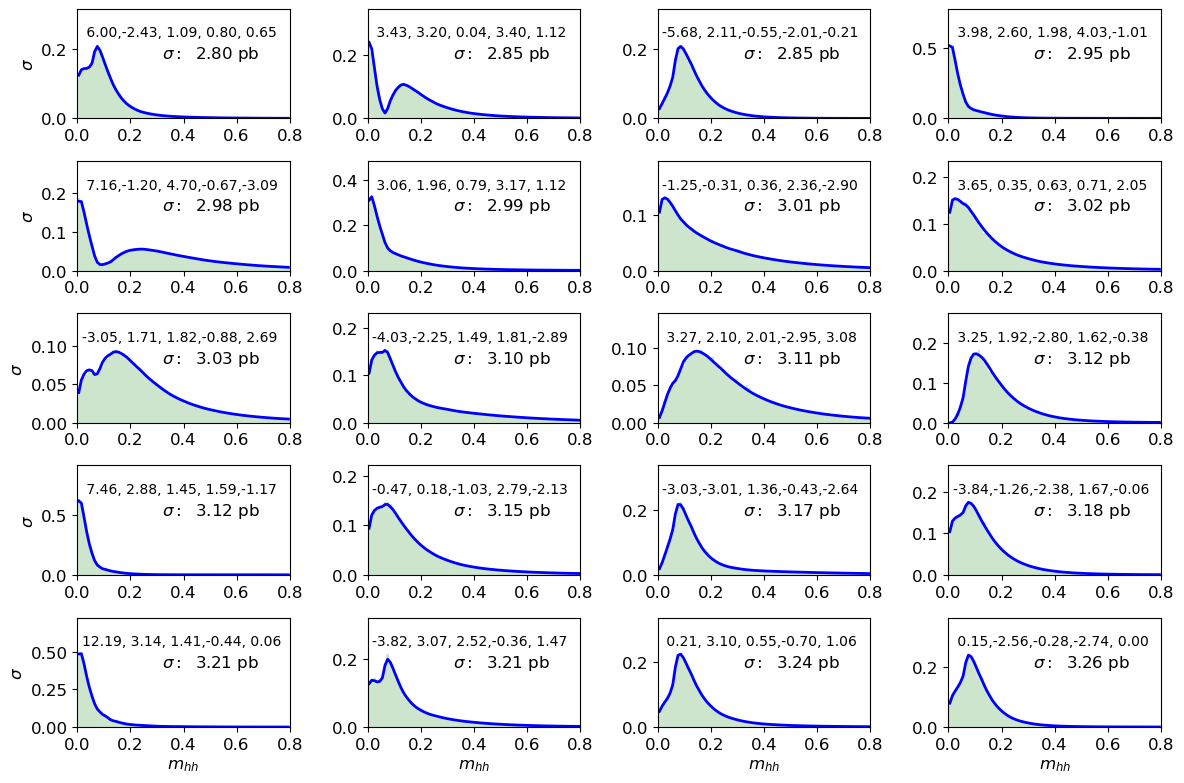

260 280
runs/L1Loss/figures/spectra014.png


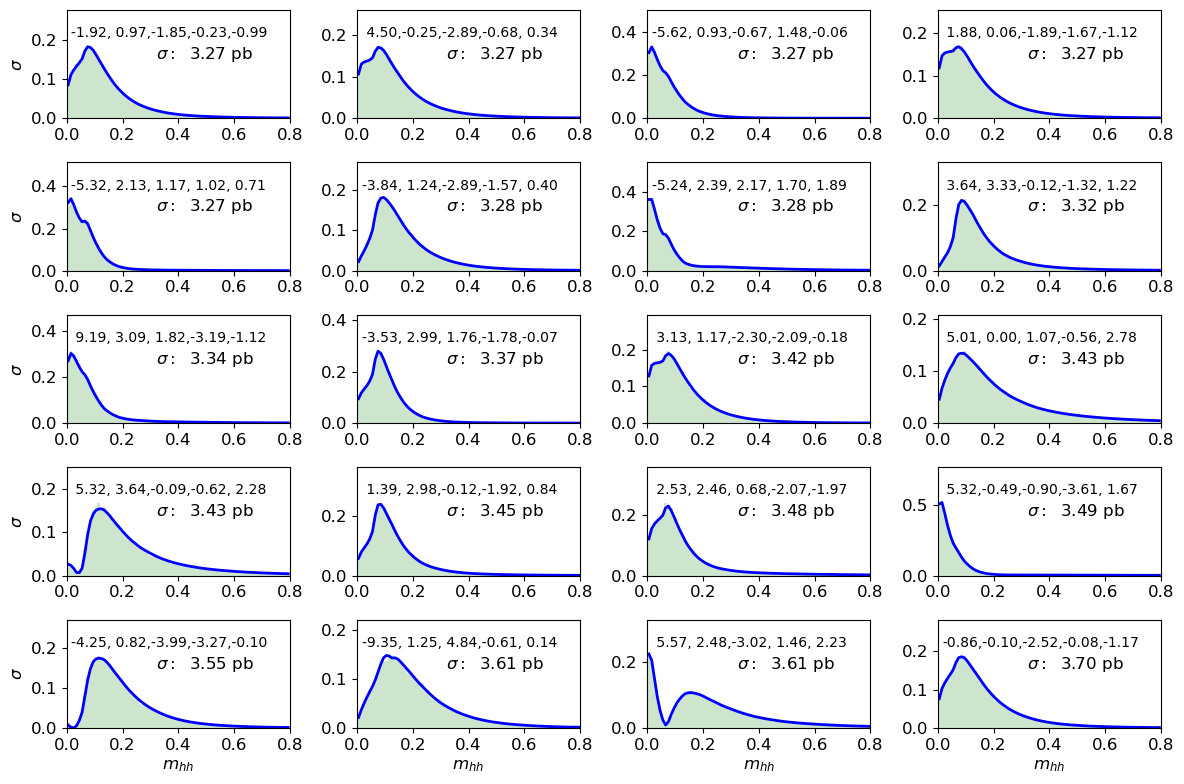

280 300
runs/L1Loss/figures/spectra015.png


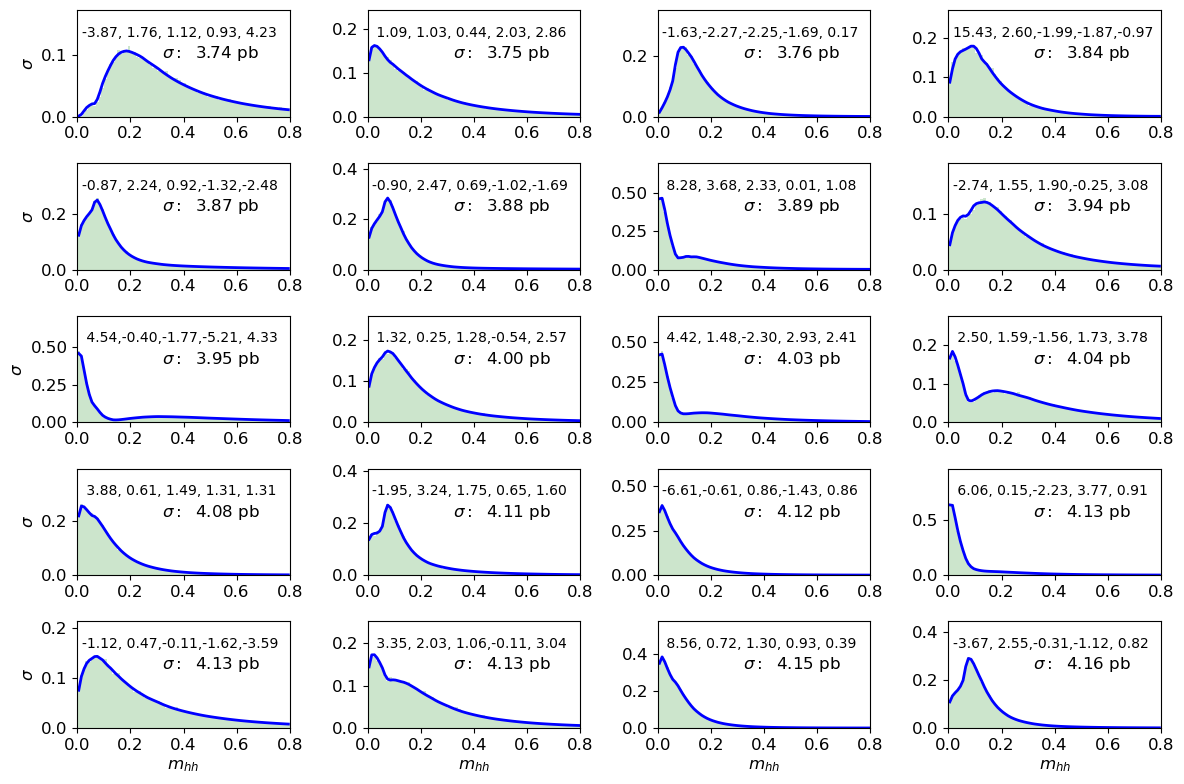

300 320
runs/L1Loss/figures/spectra016.png


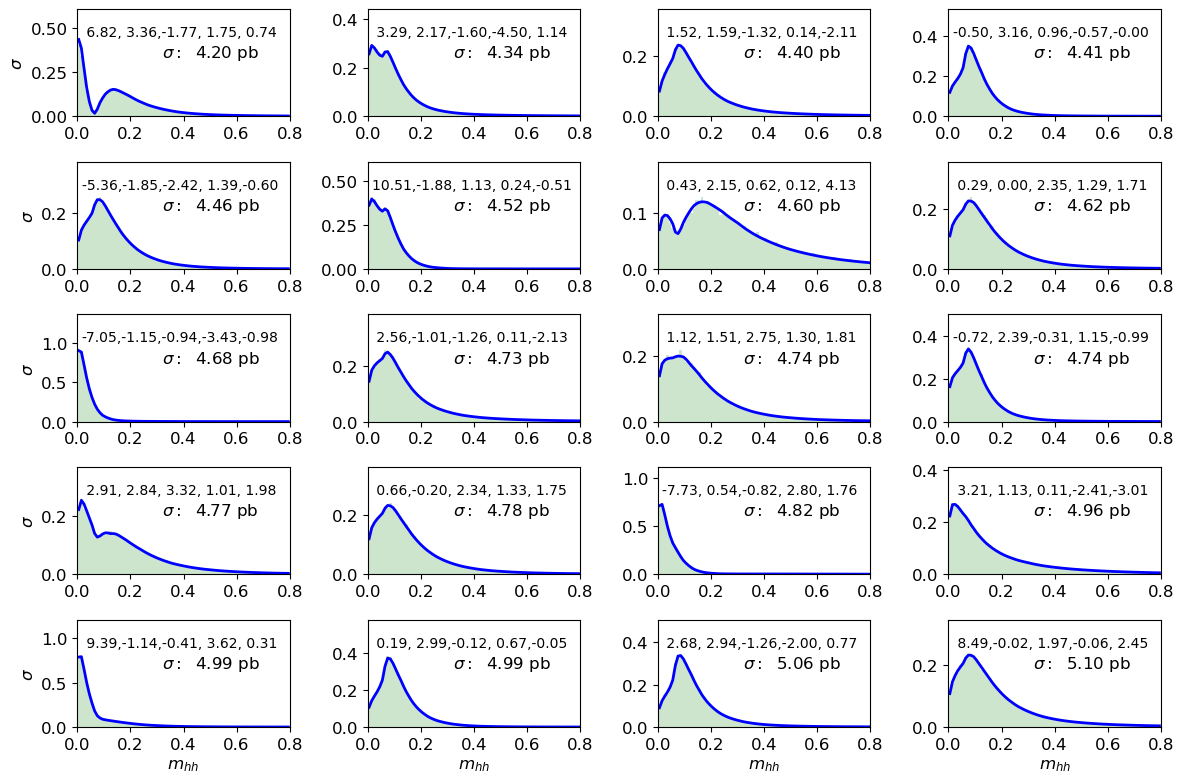

320 340
runs/L1Loss/figures/spectra017.png


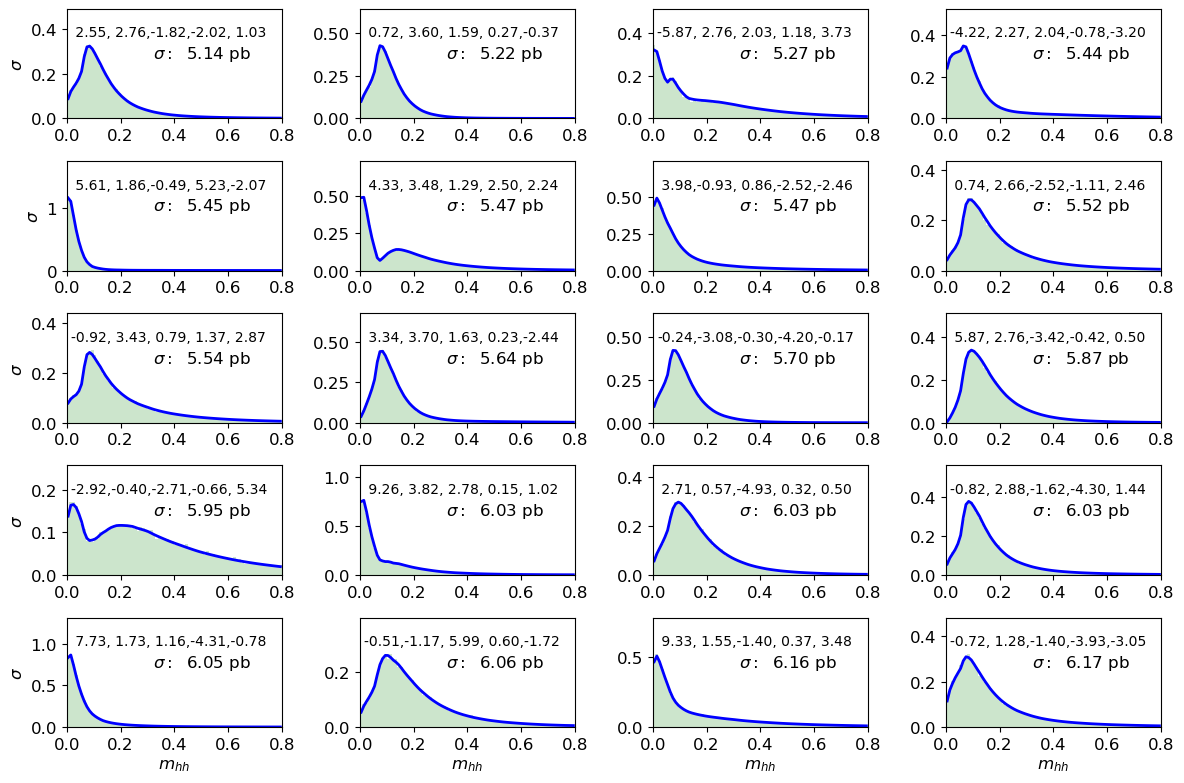

340 360
runs/L1Loss/figures/spectra018.png


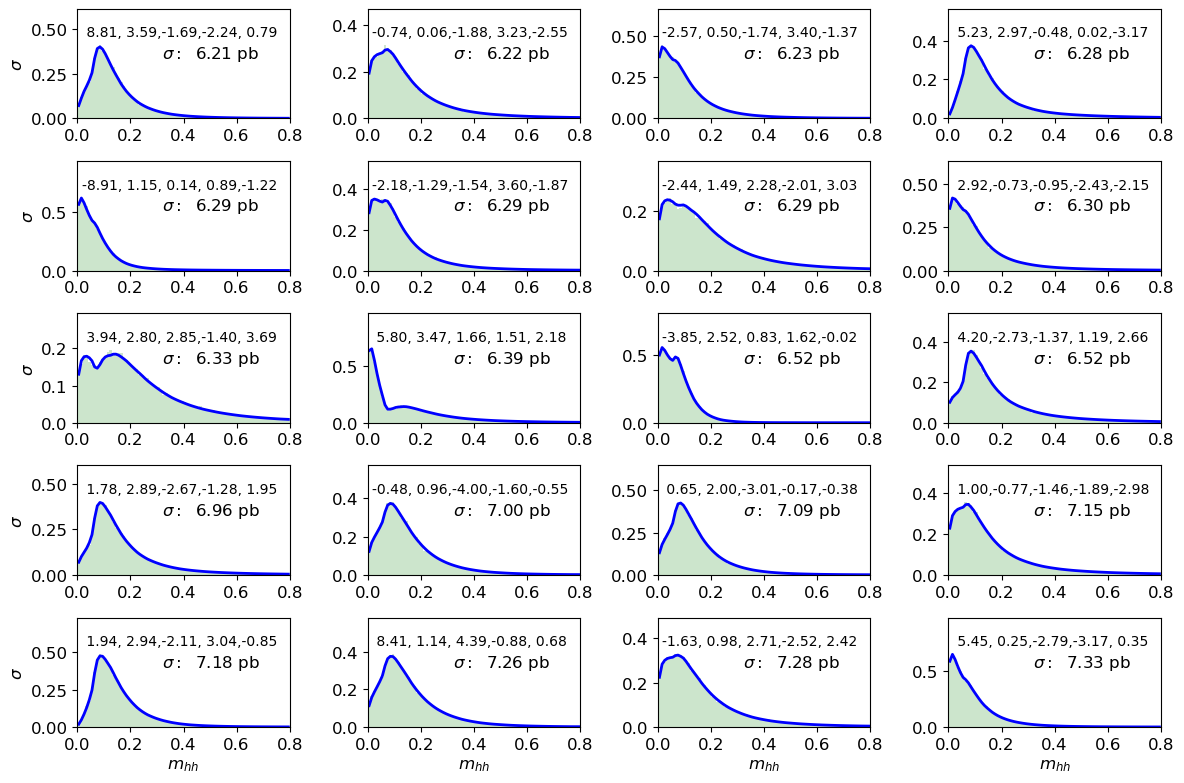

360 380
runs/L1Loss/figures/spectra019.png


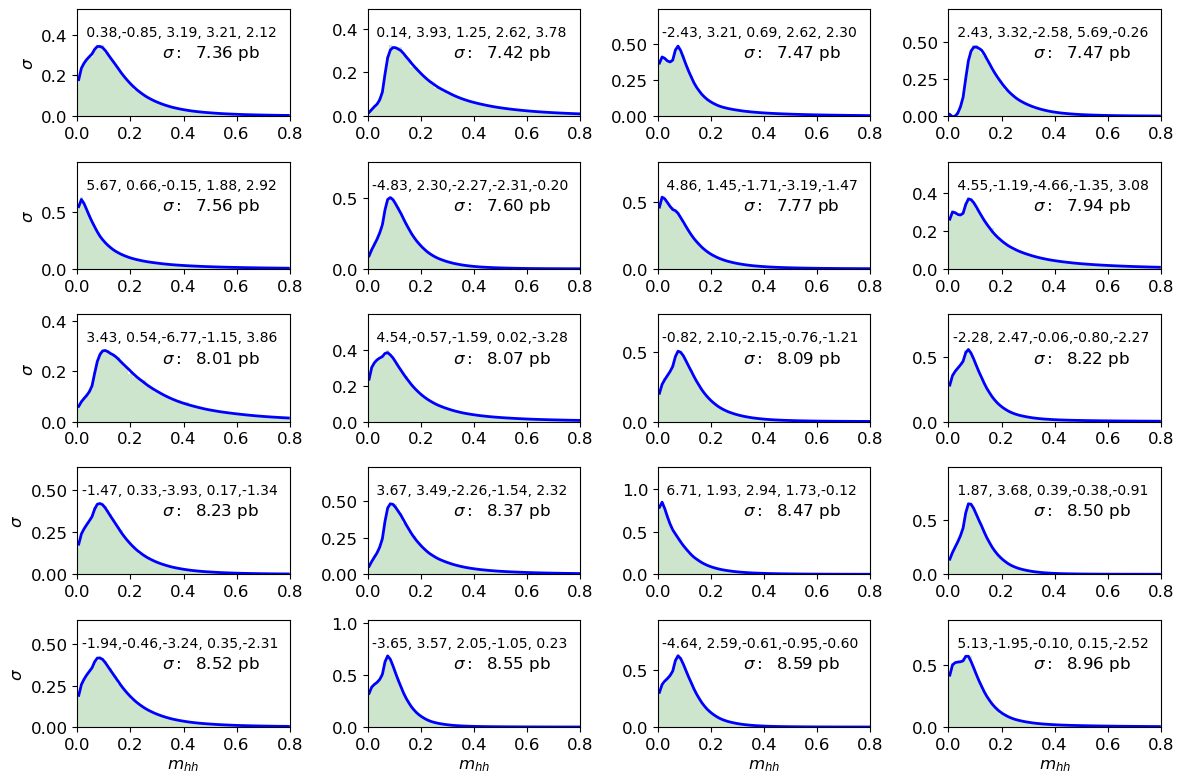

380 400
runs/L1Loss/figures/spectra020.png


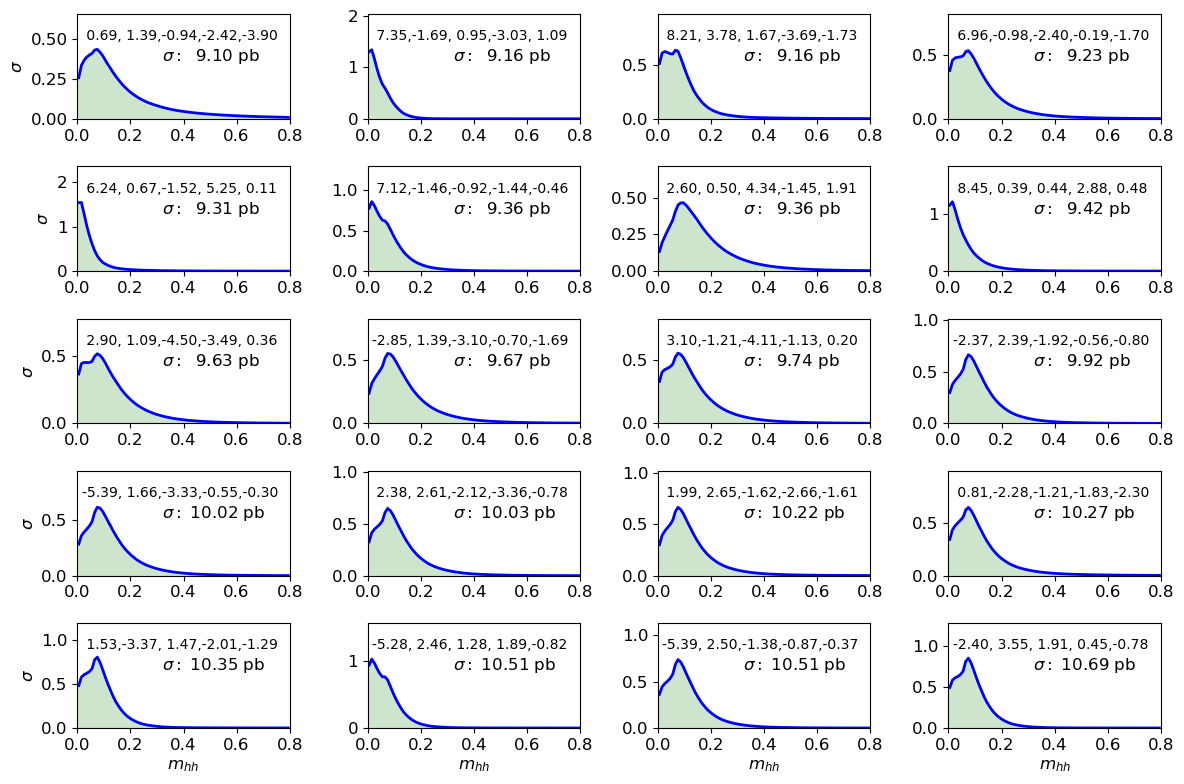

400 420
runs/L1Loss/figures/spectra021.png


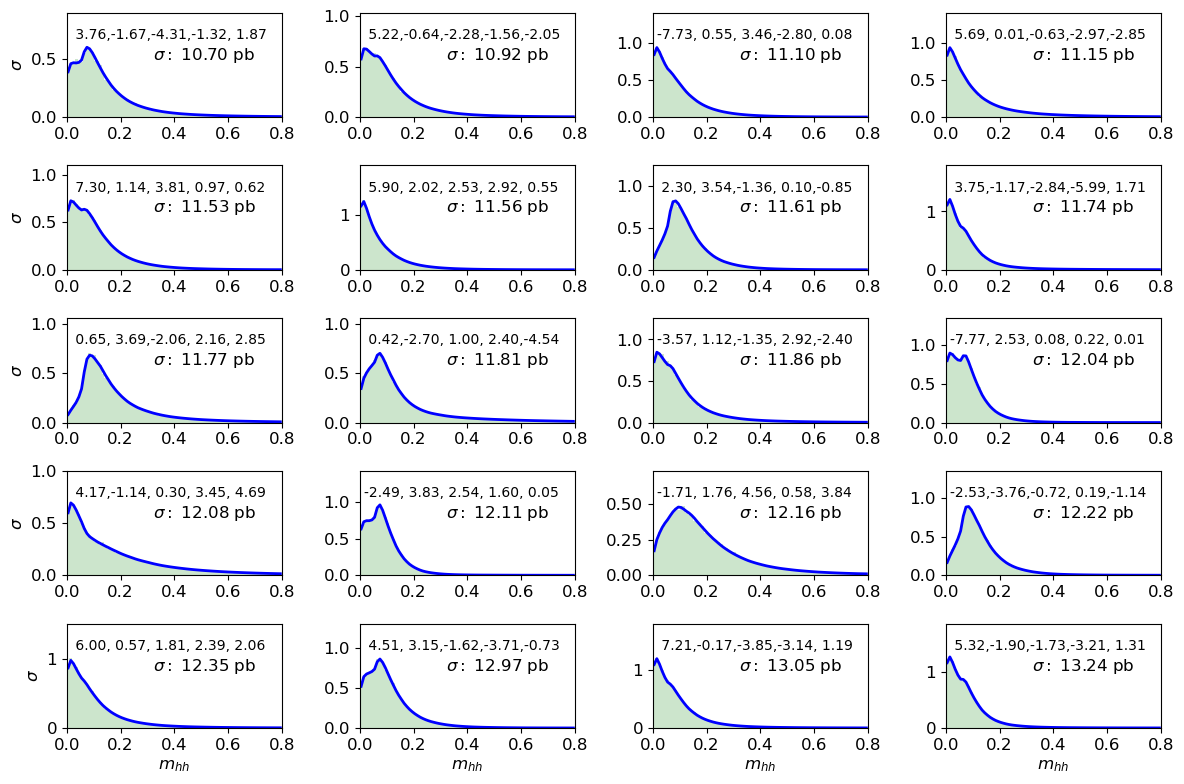

420 440
runs/L1Loss/figures/spectra022.png


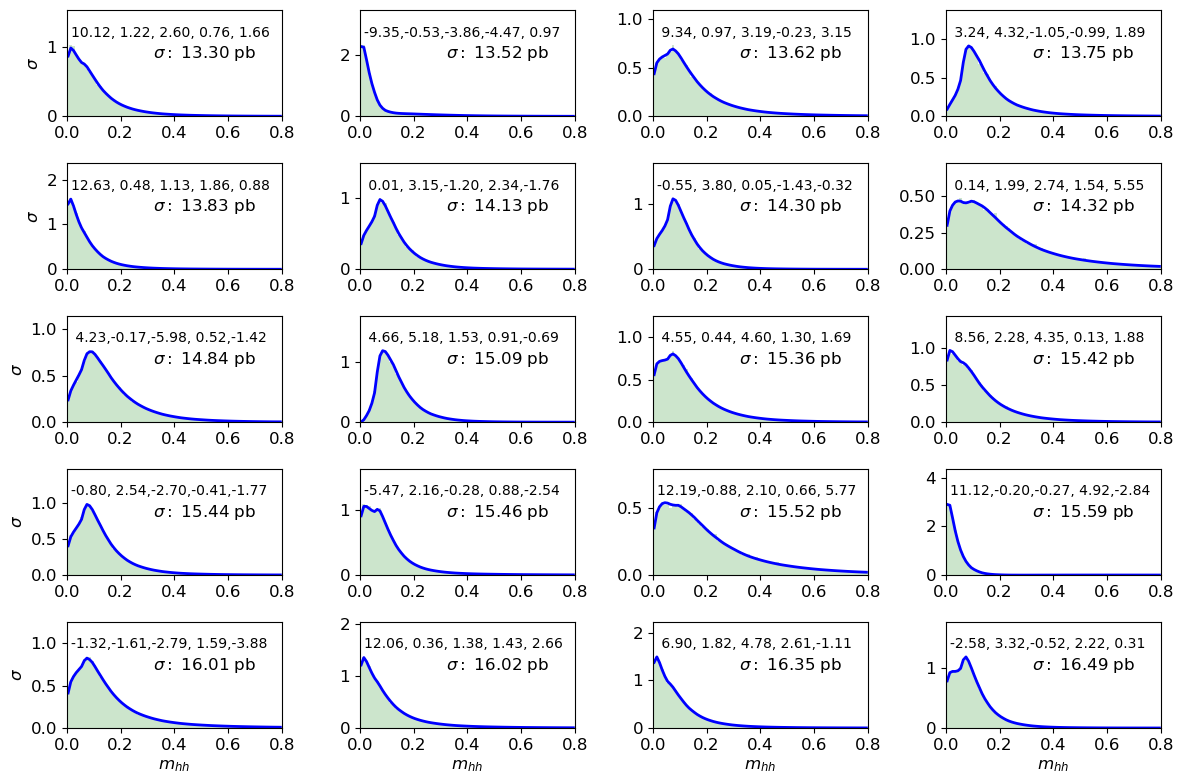

440 460
runs/L1Loss/figures/spectra023.png


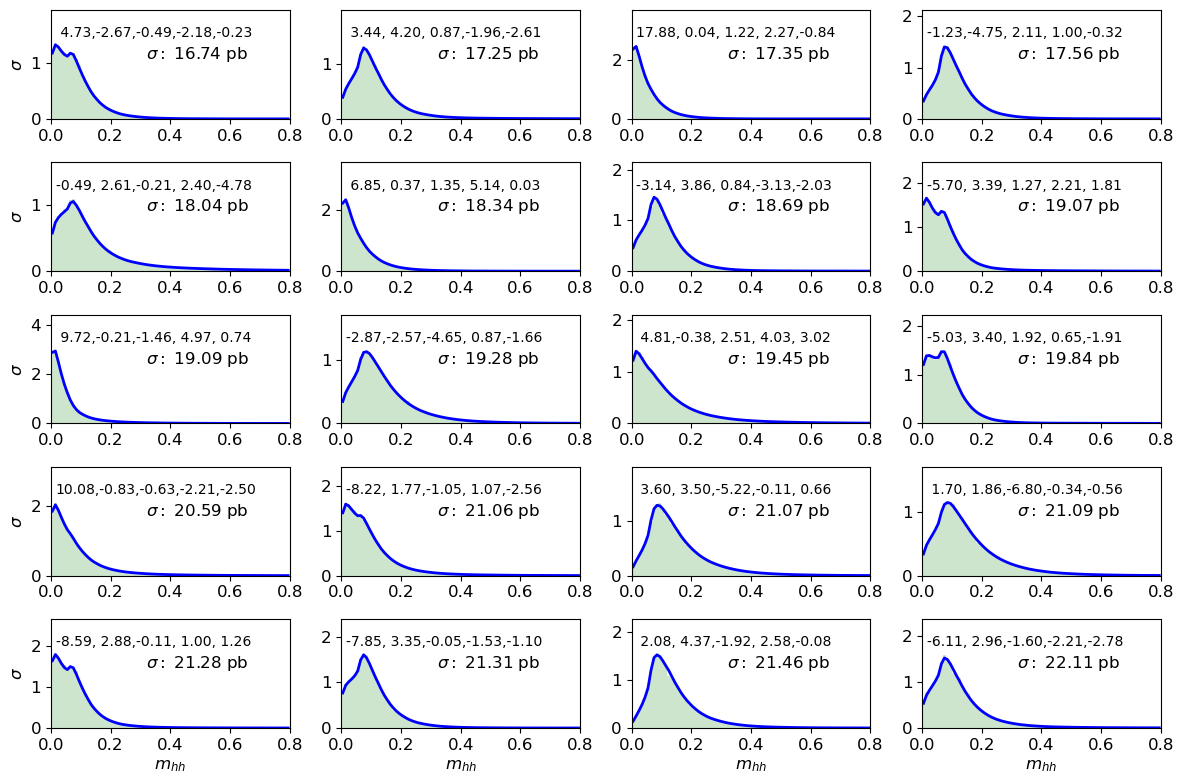

460 480
runs/L1Loss/figures/spectra024.png


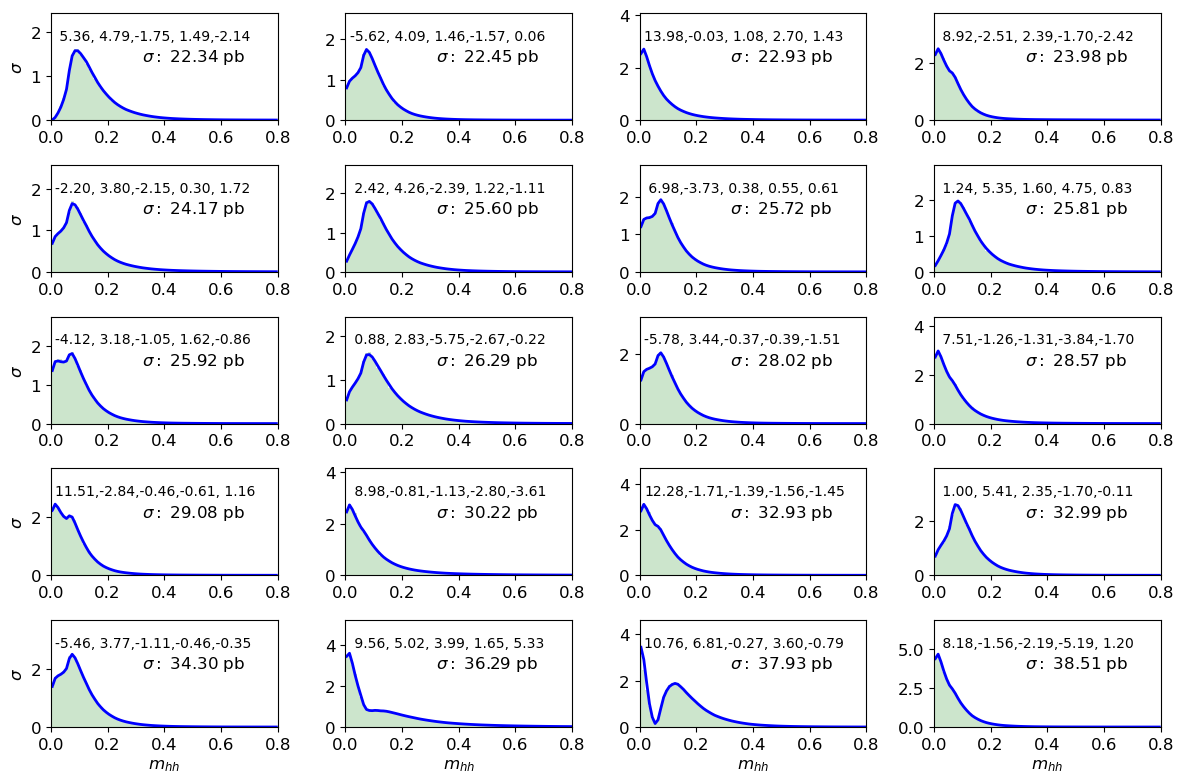

480 500
runs/L1Loss/figures/spectra025.png


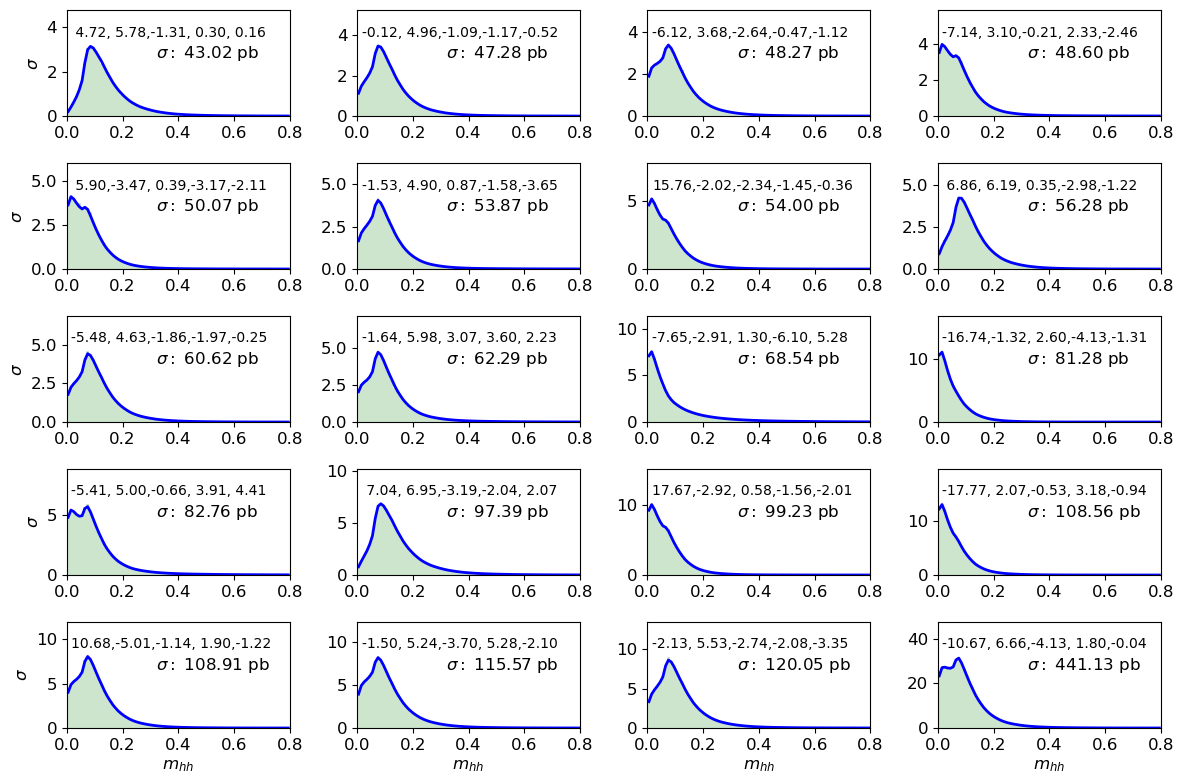

In [12]:
os.system(f'mkdir -p {BASE}/figures')
K = 20
J = int(M / K)
for j in range(J):
    i = j + 1
    filename=f'{BASE}/figures/spectra%3.3d.png' % i
    start = j * K
    end   = start + K
    print(start, end)
    plot_spectra(data[start:end], filename=filename)